# 03 — PU-Bagging Model

**Задача:** Positive-Unlabeled Learning — найти скрытых предпринимателей среди consumer-карт.

**Пайплайн:**
1. Baseline: Logistic Regression
2. Основная модель: PU-Bagging + LightGBM (N=10 итераций)
3. Challenger: PU-Bagging + CatBoost
4. Валидация: PR-AUC, ROC-AUC, Confusion Matrix, Precision@K
5. Synthetic Injection Test (оценка recall)
6. SHAP: объяснение модели

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.models.train import load_feature_matrix, prepare_splits, save_model, load_model
from src.models.baseline import build_baseline
from src.models.pu_bagging import PUBaggingClassifier
from src.models.catboost_model import PUBaggingCatBoost
from src.evaluation.metrics import evaluate_on_holdout, precision_at_k_table
from src.evaluation.plots import (
    plot_pr_curve, plot_roc_curve, plot_confusion_matrix,
    plot_score_distribution, plot_precision_at_k, plot_feature_importance,
)
from src.evaluation.injection_test import run_injection_test
from src.config import DEFAULT_THRESHOLD, MODELS_DIR

MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных и сплит

In [2]:
fm = load_feature_matrix()
X_pos_train, X_pos_holdout, X_unlabeled, X_con_holdout, feature_cols = prepare_splits(fm)

print(f"Positives (train):    {len(X_pos_train):,}")
print(f"Positives (holdout):  {len(X_pos_holdout):,}")
print(f"Unlabeled consumer:   {len(X_unlabeled):,}  ← PU-bagging pseudo-negatives")
print(f"Consumer holdout:     {len(X_con_holdout):,}  ← честная оценка, не видели при обучении")
print(f"Features:             {len(feature_cols)}")

# Eval set: 5K biz holdout (label=1) + 16K consumer holdout (label=0, не были в train)
y_holdout_all = np.concatenate([np.ones(len(X_pos_holdout)), np.zeros(len(X_con_holdout))])
X_holdout_all = pd.concat([X_pos_holdout, X_con_holdout], ignore_index=True)
print(f"\nEval set: {len(X_holdout_all):,} cards  ({len(X_pos_holdout):,} biz + {len(X_con_holdout):,} consumer holdout)")

Positives (train):    20,000
Positives (holdout):  5,000
Unlabeled consumer:   64,000  ← PU-bagging pseudo-negatives
Consumer holdout:     16,000  ← честная оценка, не видели при обучении
Features:             63

Eval set: 21,000 cards  (5,000 biz + 16,000 consumer holdout)


## 2. Baseline: Logistic Regression

In [3]:
# Baseline обучается на (20K biz train + 64K consumer unlabeled)
# Оценивается на (5K biz holdout + 16K consumer holdout) — чистый holdout без leakage
y_baseline_train = np.concatenate([
    np.ones(len(X_pos_train)),
    np.zeros(len(X_unlabeled)),
])
X_baseline_train = pd.concat([X_pos_train, X_unlabeled], ignore_index=True)

baseline = build_baseline(X_baseline_train, y_baseline_train)
save_model(baseline, "baseline_logreg")

scores_baseline = baseline.predict_proba(X_holdout_all)[:, 1]
metrics_baseline = evaluate_on_holdout(y_holdout_all, scores_baseline, label="LogReg Baseline")

Saved → c:\Users\Yeska\OneDrive\Desktop\mdq-hackathon_1\notebooks\..\models\baseline_logreg.pkl
[LogReg Baseline] ROC-AUC:  1.0000
[LogReg Baseline] PR-AUC:   1.0000  ← основная метрика
[LogReg Baseline] F1:       0.9999  (threshold=0.7)

[LogReg Baseline] Confusion Matrix:
[[16000     0]
 [    1  4999]]

[LogReg Baseline] Classification Report:
              precision    recall  f1-score   support

    consumer       1.00      1.00      1.00     16000
    business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



## 3. PU-Bagging + LightGBM (основная модель)

~10-15 минут на 10 итерациях.

In [4]:
pu_lgbm = PUBaggingClassifier(n_iterations=10)
pu_lgbm.fit(X_pos_train, X_unlabeled, verbose=True)
save_model(pu_lgbm, "pu_bagging_lgbm")

scores_lgbm = pu_lgbm.predict_proba_business(X_holdout_all)
metrics_lgbm = evaluate_on_holdout(y_holdout_all, scores_lgbm, label="PU-LightGBM")

PU-Bagging: 100%|██████████| 10/10 [00:15<00:00,  1.54s/it]


Saved → c:\Users\Yeska\OneDrive\Desktop\mdq-hackathon_1\notebooks\..\models\pu_bagging_lgbm.pkl
[PU-LightGBM] ROC-AUC:  1.0000
[PU-LightGBM] PR-AUC:   1.0000  ← основная метрика
[PU-LightGBM] F1:       0.9997  (threshold=0.7)

[PU-LightGBM] Confusion Matrix:
[[15998     2]
 [    1  4999]]

[PU-LightGBM] Classification Report:
              precision    recall  f1-score   support

    consumer       1.00      1.00      1.00     16000
    business       1.00      1.00      1.00      5000

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000



## 4. Сравнение моделей: PR-кривые и ROC

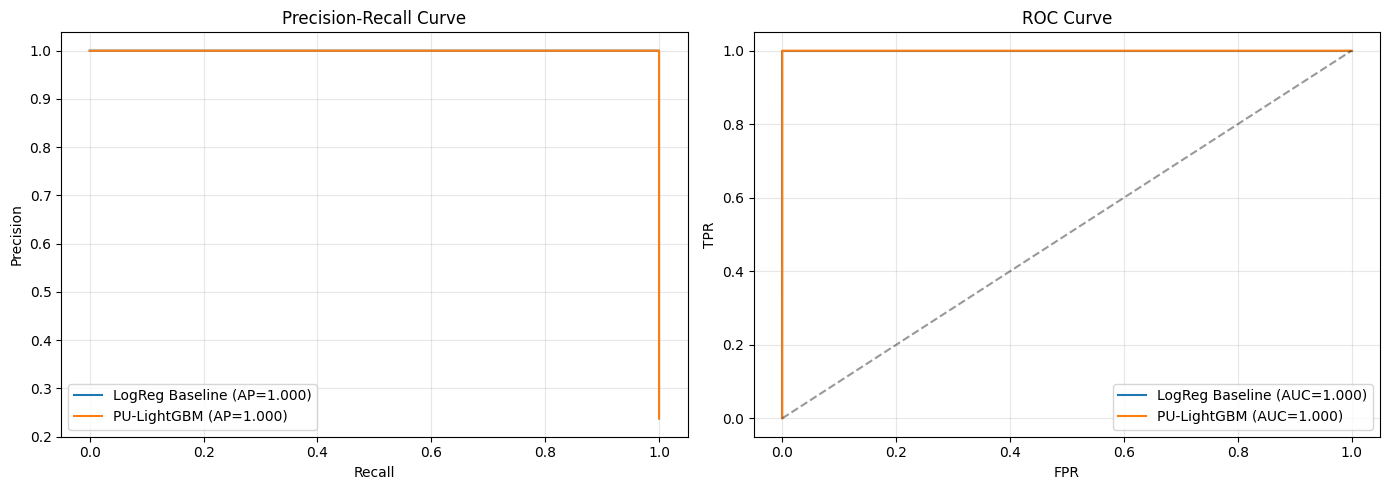

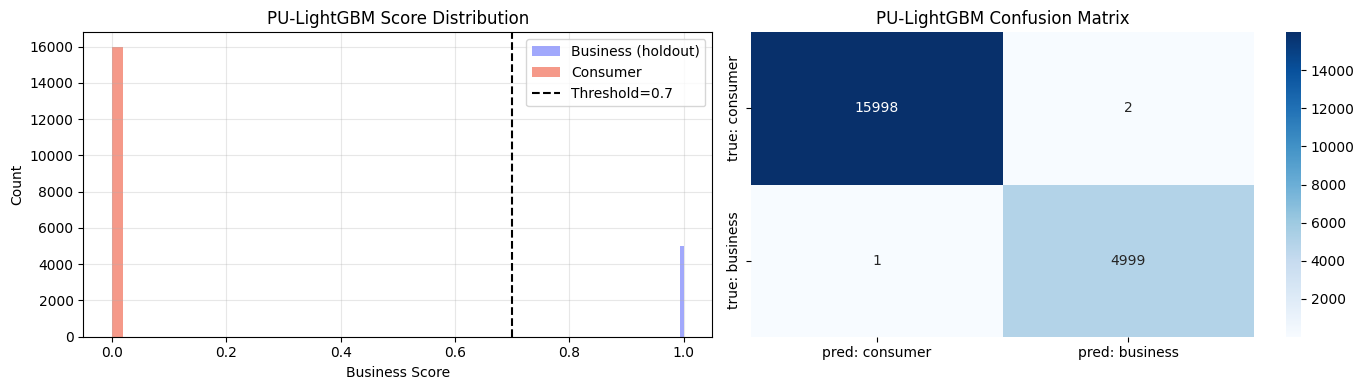

In [5]:
all_scores = {
    "LogReg Baseline": scores_baseline,
    "PU-LightGBM": scores_lgbm,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_pr_curve(y_holdout_all, all_scores, ax=axes[0])
plot_roc_curve(y_holdout_all, all_scores, ax=axes[1])
plt.tight_layout()
plt.show()

# Score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_score_distribution(
    scores_lgbm[:len(X_pos_holdout)],
    scores_lgbm[len(X_pos_holdout):],
    threshold=DEFAULT_THRESHOLD,
    ax=axes[0],
)
axes[0].set_title("PU-LightGBM Score Distribution")

plot_confusion_matrix(metrics_lgbm["confusion_matrix"], title="PU-LightGBM Confusion Matrix", ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Precision@K — бизнес-метрика

PU-LightGBM:
   K  Precision@K
 100       1.0000
 500       1.0000
1000       1.0000
2000       1.0000
5000       0.9998

LogReg Baseline:
   K  Precision@K
 100          1.0
 500          1.0
1000          1.0
2000          1.0
5000          1.0


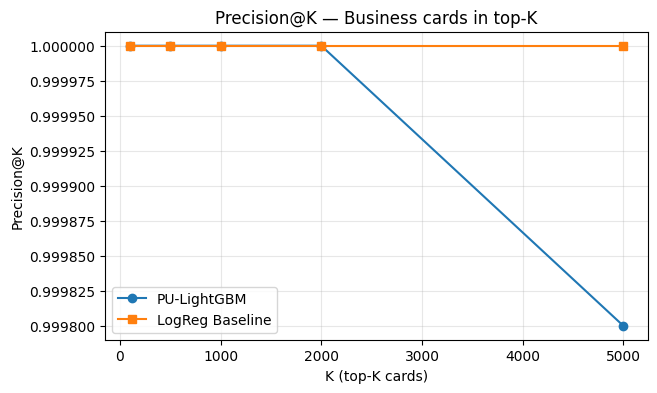

In [6]:
pk_lgbm = precision_at_k_table(y_holdout_all, scores_lgbm)
pk_baseline = precision_at_k_table(y_holdout_all, scores_baseline)

print("PU-LightGBM:")
print(pk_lgbm.to_string(index=False))
print("\nLogReg Baseline:")
print(pk_baseline.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pk_lgbm["K"], pk_lgbm["Precision@K"], marker="o", label="PU-LightGBM")
ax.plot(pk_baseline["K"], pk_baseline["Precision@K"], marker="s", label="LogReg Baseline")
ax.set_xlabel("K (top-K cards)")
ax.set_ylabel("Precision@K")
ax.set_title("Precision@K — Business cards in top-K")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. Synthetic Injection Test — оценка recall

Берём 1000 business holdout-карт, вколоть в consumer pool, смотрим сколько попало в top-5%.

Synthetic Injection Test:
  Injected: 1000 business cards into 64000 consumer pool
  Pool size: 65,000
  Top-5% = 3,250 cards
  Found:    1000 / 1000  →  Recall = 1.000


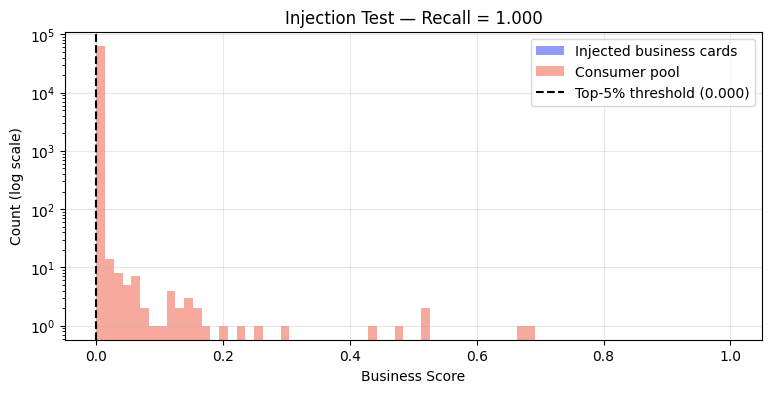

In [7]:
inject_result = run_injection_test(
    pu_model=pu_lgbm,
    X_pos_holdout=X_pos_holdout,
    X_unlabeled=X_unlabeled,
    n_inject=1000,
    top_pct=0.05,
    verbose=True,
)

# Visualize injected vs non-injected score distribution
inj_scores = inject_result["scores"]
inj_flags = inject_result["inject_flags"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(inj_scores[inj_flags], bins=50, alpha=0.7, label="Injected business cards", color="#636EFA")
ax.hist(inj_scores[~inj_flags], bins=50, alpha=0.5, label="Consumer pool", color="#EF553B")
top_k_threshold = np.sort(inj_scores)[::-1][inject_result["top_k"]]
ax.axvline(top_k_threshold, color="black", linestyle="--",
           label=f"Top-5% threshold ({top_k_threshold:.3f})")
ax.set_xlabel("Business Score")
ax.set_ylabel("Count (log scale)")
ax.set_yscale("log")
ax.set_title(f"Injection Test — Recall = {inject_result['recall']:.3f}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. SHAP — объяснение модели

c:\Users\Yeska\OneDrive\Desktop\mdq-hackathon_1\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


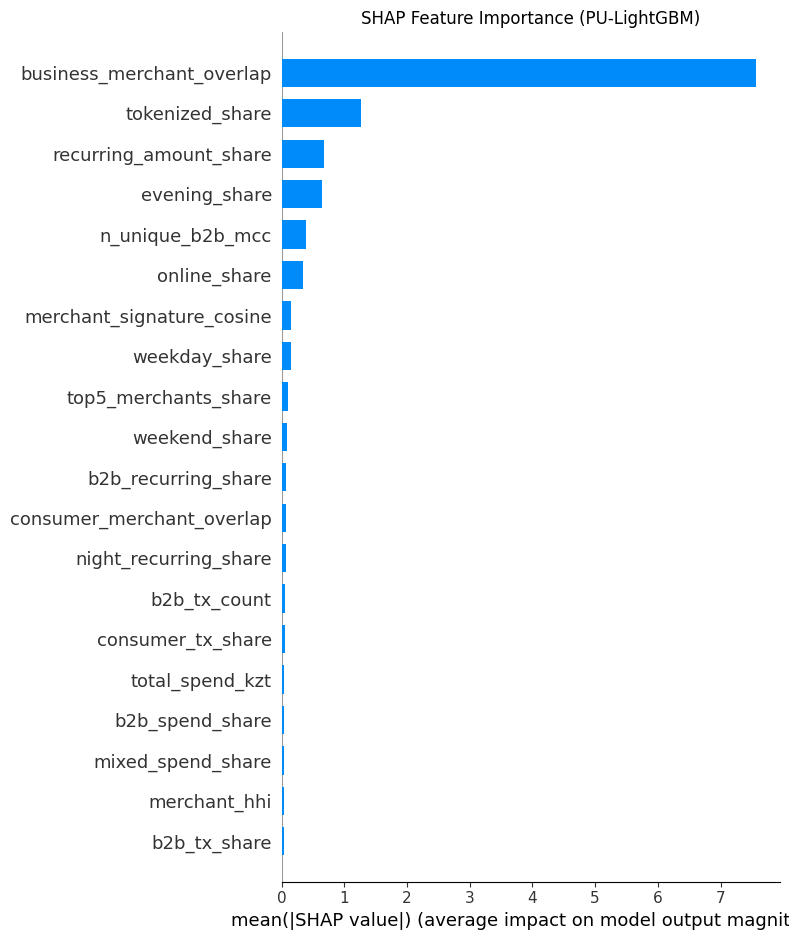

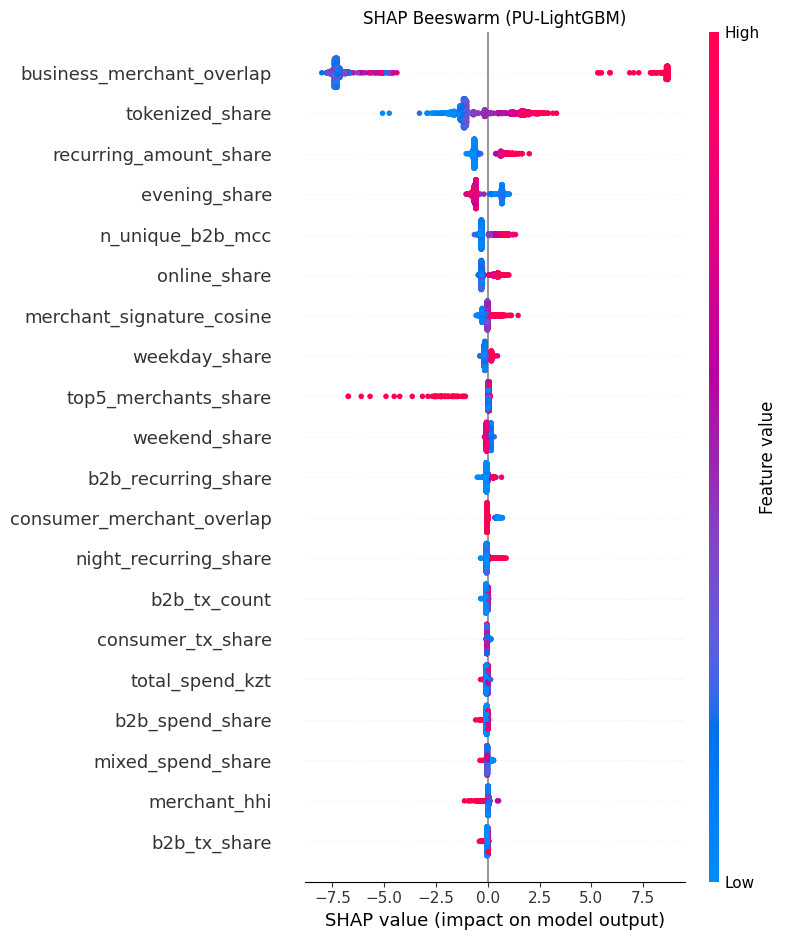

In [8]:
# SHAP на последней (или средней) модели из PU-bagging
# Используем sample для скорости
sample_size = min(2000, len(X_holdout_all))
X_shap = X_holdout_all.sample(sample_size, random_state=42)

explainer = shap.TreeExplainer(pu_lgbm.models_[-1])
shap_values = explainer.shap_values(X_shap)

# Если список (бинарная классификация) — берём класс 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure()
shap.summary_plot(sv, X_shap, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance (PU-LightGBM)")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(sv, X_shap, show=False, max_display=20)
plt.title("SHAP Beeswarm (PU-LightGBM)")
plt.tight_layout()
plt.show()

## 8. Скоринг всех consumer-карт → hidden entrepreneurs

=== Score distribution по порогам ===
  threshold=0.70: 2 cards (0.0%)
  threshold=0.50: 8 cards (0.0%)
  threshold=0.30: 11 cards (0.0%)
  threshold=0.10: 33 cards (0.0%)
  threshold=0.05: 49 cards (0.1%)
  threshold=0.01: 88 cards (0.1%)

Top-6% prior (4,800 cards): score >= 0.0000

Hidden entrepreneurs (top-6%): 4,801 cards
Saved → c:\Users\Yeska\OneDrive\Desktop\mdq-hackathon_1\notebooks\..\data\processed\consumer_scored.parquet


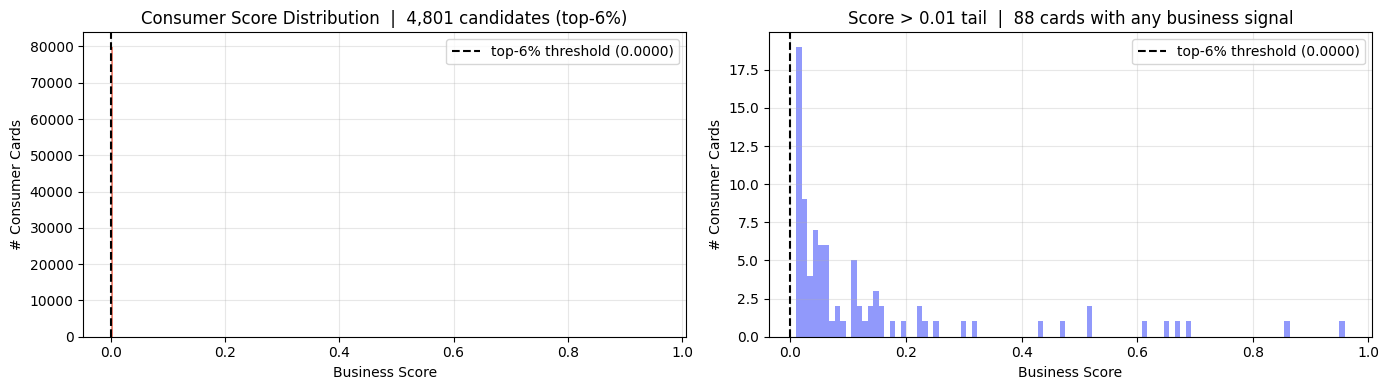

In [9]:
import polars as pl
from src.config import PROCESSED_DIR, HIDDEN_ENTREPRENEUR_SHARE

# Скорим все 80K consumer-карт через predict_proba_business (mean по N моделям).
consumer_fm = fm.filter(pl.col("label") == 0).to_pandas().reset_index(drop=True)
all_consumer_scores = pu_lgbm.predict_proba_business(consumer_fm[feature_cols])
consumer_fm["business_score"] = all_consumer_scores

# --- Порог по prior из бизнес-кейса: 6% от 80K = 4800 карт ---
n_hidden_prior = int(len(consumer_fm) * HIDDEN_ENTREPRENEUR_SHARE)
threshold_topn = float(sorted(all_consumer_scores, reverse=True)[n_hidden_prior])

print("=== Score distribution по порогам ===")
for thr in [0.7, 0.5, 0.3, 0.1, 0.05, 0.01]:
    n = (all_consumer_scores >= thr).sum()
    print(f"  threshold={thr:.2f}: {n:,} cards ({n/len(consumer_fm)*100:.1f}%)")

print(f"\nTop-{HIDDEN_ENTREPRENEUR_SHARE*100:.0f}% prior ({n_hidden_prior:,} cards): score >= {threshold_topn:.4f}")

# Сохраняем по prior-порогу
hidden = consumer_fm[consumer_fm["business_score"] >= threshold_topn]
print(f"\nHidden entrepreneurs (top-{HIDDEN_ENTREPRENEUR_SHARE*100:.0f}%): {len(hidden):,} cards")

scored_path = PROCESSED_DIR / "consumer_scored.parquet"
pl.from_pandas(consumer_fm[["card_number", "business_score"] + feature_cols]).write_parquet(scored_path)
print(f"Saved → {scored_path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Полное распределение
axes[0].hist(all_consumer_scores, bins=200, color="#EF553B", alpha=0.7)
axes[0].axvline(threshold_topn, color="black", linestyle="--",
                label=f"top-6% threshold ({threshold_topn:.4f})")
axes[0].set_xlabel("Business Score")
axes[0].set_ylabel("# Consumer Cards")
axes[0].set_title(f"Consumer Score Distribution  |  {len(hidden):,} candidates (top-6%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Хвост (score > 0.01) — скрытые предприниматели
tail = all_consumer_scores[all_consumer_scores > 0.01]
axes[1].hist(tail, bins=100, color="#636EFA", alpha=0.7)
axes[1].axvline(threshold_topn, color="black", linestyle="--",
                label=f"top-6% threshold ({threshold_topn:.4f})")
axes[1].set_xlabel("Business Score")
axes[1].set_ylabel("# Consumer Cards")
axes[1].set_title(f"Score > 0.01 tail  |  {len(tail):,} cards with any business signal")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("=== ИТОГИ ===")
print(f"Baseline  ROC-AUC={metrics_baseline['roc_auc']:.4f}  PR-AUC={metrics_baseline['pr_auc']:.4f}")
print(f"PU-LightGBM  ROC-AUC={metrics_lgbm['roc_auc']:.4f}  PR-AUC={metrics_lgbm['pr_auc']:.4f}")
print(f"Injection Test Recall@top5%: {inject_result['recall']:.3f}")
print()
print(f"Scoring strategy: top-{HIDDEN_ENTREPRENEUR_SHARE*100:.0f}% prior")
print(f"Hidden entrepreneurs: {len(hidden):,} карт из {len(consumer_fm):,}")
print(f"Threshold (top-6%): {threshold_topn:.4f}")
print()
print("Топ SHAP-фичи: business_merchant_overlap, tokenized_share, evening_share, online_share")
print("\nNext: 04_segmentation.ipynb — KMeans сегментация найденных кандидатов")

=== ИТОГИ ===
Baseline  ROC-AUC=1.0000  PR-AUC=1.0000
PU-LightGBM  ROC-AUC=1.0000  PR-AUC=1.0000
Injection Test Recall@top5%: 1.000

Scoring strategy: top-6% prior
Hidden entrepreneurs: 4,801 карт из 80,000
Threshold (top-6%): 0.0000

Топ SHAP-фичи: business_merchant_overlap, tokenized_share, evening_share, online_share

Next: 04_segmentation.ipynb — KMeans сегментация найденных кандидатов
